# Lab 1: Tree-Based Classification
**Titanic Survival Prediction**

### **Goal**:
In this lab, I tackle a classic binary classification problem—predicting who survived the Titanic disaster—using decision trees.

1. **Load & Explore**

   * Fetch the Titanic dataset from OpenML and inspect its structure.
   * Surface data‐quality issues (missing values, outliers, class balance).

2. **Prepare & Clean**

   * Drop irrelevant columns (e.g. name, ticket, cabin).
   * Impute or otherwise handle missing values.
   * Encode categorical fields (sex, embarked) into numeric form.

3. **Train & Evaluate an Unpruned Tree**

   * Split into stratified train/test sets.
   * Fit a vanilla `DecisionTreeClassifier`.
   * Measure train vs. test accuracy; generate a classification report and confusion matrix.
   * Note tree complexity (depth & node count) and signs of overfitting.

4. **Analyze Feature Relationships**

   * Compute & visualize a feature‐to‐feature correlation matrix.
   * Plot feature importances from the fitted tree.

5. **Cost–Complexity Pruning**

   * Extract the pruning path (`ccp_alphas`) for the trained tree.
   * Train a family of trees across that α–spectrum, tracking train/test accuracy.
   * Identify the α that maximizes test performance.

6. **Retrain & Reassess**

   * Refit a `DecisionTreeClassifier(ccp_alpha=…)` using the chosen α.
   * Recompute all metrics (accuracy, classification report, confusion matrix).
   * Visualize the final, pruned tree structure.

7. **Conclude & Reflect**

   * Compare pruned vs. unpruned models in terms of complexity and generalization.
   * Summarize key take-aways about decision-tree overfitting, pruning, and interpretability.


## **Dependencies**:

In [1]:
# Core data science libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading & splitting
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Model & tree utilities
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Check scikit-learn version
from sklearn import __version__ as ver
print(f"scikit-learn version: {ver}")

scikit-learn version: 1.6.0


## **Data**:
### **Load the Titanic dataset from OpenML**:

In [2]:
X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)
# Convert the target to a categorical dtype
y = y.astype("category")

### **Explore the Data**:

In [3]:
# target
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1309 entries, 0 to 1308
Series name: survived
Non-Null Count  Dtype   
--------------  -----   
1309 non-null   category
dtypes: category(1)
memory usage: 1.5 KB


In [4]:
print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
survived
0    809
1    500
Name: count, dtype: int64


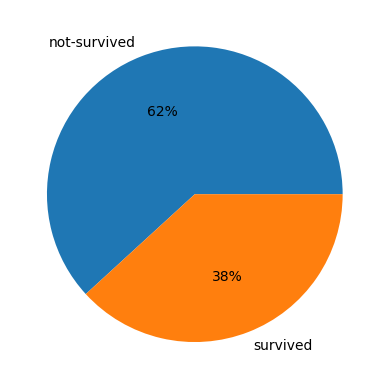

In [5]:
plt.pie(
    y.value_counts(),
    labels=['not-survived', 'survived'],
    autopct='%1.0f%%'
)
plt.show()

In [6]:
# Features
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   object  
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   object  
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    object  
 9   embarked   1307 non-null   category
 10  boat       486 non-null    object  
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    object  
dtypes: category(2), float64(3), int64(3), object(5)
memory usage: 115.4+ KB


In [7]:
# Peek at the very first few rows of both
display(X.head(), y.head())

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


0    1
1    1
2    0
3    0
4    0
Name: survived, dtype: category
Categories (2, object): ['0', '1']

### **Check for missing values**:

In [8]:
# Check for missing values
missing_counts = X.isnull().sum()
missing_counts[missing_counts > 0]


age           263
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

### Observations
Here’s what I’ve observed so far:

* **Target balance:**

  * Only about 38% of passengers survived (500/1 309), so the classes are somewhat imbalanced.

* **Feature set:**

  * We initially have 13 columns including things like `name`, `ticket`, `cabin`, `boat`, `body`, and `home.dest` that are unlikely to be predictive or are too sparsely populated.
  * The core numeric/categorical features are `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, and `embarked`.

* **Missing data:**

  * `cabin`, `body`, and `boat` are missing in well over half of the rows (1 014, 1 188, and 823 nulls respectively).
  * `home.dest` has 564 nulls.
  * `age` is missing in 263 rows (\~20%), and `embarked` in 2 rows, while only 1 missing in `fare`.
  * This pattern tells me to **drop** the extremely sparse columns (`cabin`, `boat`, `body`, `home.dest`) plus the unneeded identifiers (`name`, `ticket`), and then **impute** the handful of remaining nulls in `age`, `fare`, and `embarked`.

* **Next steps:**

  1. Drop those irrelevant/sparse columns.
  2. Impute `age` and `fare` with their medians, and fill `embarked` with its mode.


### **Remove Irrelevant/Sparse Columns**:

In [9]:
irrelevant_cols = ['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest']
X.drop(columns=irrelevant_cols, inplace=True)

# Quick look at the remaining features
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,29.0000,0,0,211.3375,S
1,1,male,0.9167,1,2,151.5500,S
2,1,female,2.0000,1,2,151.5500,S
3,1,male,30.0000,1,2,151.5500,S
4,1,female,25.0000,1,2,151.5500,S


### **Impute Missing Values**:

In [10]:
X.fillna({
    'age':      X['age'].median(),
    'fare':     X['fare'].median(),
    'embarked': X['embarked'].mode()[0]
}, inplace=True)
# Verify that no nulls remain
print("\nMissing values after imputation:")
print(X.isnull().sum()[X.isnull().sum() > 0])


Missing values after imputation:
Series([], dtype: int64)


### Observations

* **Reduced feature set**: We’ve trimmed the original 13 columns down to the seven most relevant:

  ```
  pclass, sex, age, sibsp, parch, fare, embarked
  ```
* **Missing‐value imputation**

  * `age` and `fare` have been filled with their respective medians
  * `embarked` has been filled with its mode

  > **Result:** 0 missing values remain in any column of `X`.
* **Data types**

  * Numeric: `pclass` (int), `age` (float), `sibsp` (int), `parch` (int), `fare` (float)
  * Categorical: `sex`, `embarked` (both still object/category)
* **Class balance**

  * \~62% of passengers did **not** survive, \~38% **did** survive
  * Mild imbalance that we’ll account for when splitting and evaluating

---

### Next Steps

- **Encode the categorical features**

   * Transform `sex` and `embarked` into numeric labels (e.g. via `LabelEncoder` or one-hot encoding)
- **Train/Test split**

   * Perform a stratified split to preserve the 62/38 distribution

### **Feature Encoding**:
- Convert categorical feature to numerical feature

In [12]:
le_sex      = LabelEncoder()
le_embarked = LabelEncoder()

# fit & transform each separately
X['sex']      = le_sex.fit_transform(X['sex'])
X['embarked'] = le_embarked.fit_transform(X['embarked'])

# Quick check
print("Encoded sex mapping:     ", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print("Encoded embarked mapping:", dict(zip(le_embarked.classes_, le_embarked.transform(le_embarked.classes_))))
display(X.head())

Encoded sex mapping:      {0: 0, 1: 1}
Encoded embarked mapping: {0: 0, 1: 1, 2: 2}


,pclass,sex,age,sibsp,parch,fare,embarked
0,1,0,29.0000,0,0,211.3375,2
1,1,1,0.9167,1,2,151.5500,2
2,1,0,2.0000,1,2,151.5500,2
3,1,1,30.0000,1,2,151.5500,2
4,1,0,25.0000,1,2,151.5500,2


### **Describe the Data**:

In [13]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
pclass,1309.0,2.294882,0.837836,1.0000,2.0000,3.0000,3.000,3.0000
sex,1309.0,0.644003,0.478997,0.0000,0.0000,1.0000,1.000,1.0000
age,1309.0,29.503183,12.905246,0.1667,22.0000,28.0000,35.000,80.0000
sibsp,1309.0,0.498854,1.041658,0.0000,0.0000,0.0000,1.000,8.0000
parch,1309.0,0.385027,0.865560,0.0000,0.0000,0.0000,0.000,9.0000
fare,1309.0,33.281086,51.741500,0.0000,7.8958,14.4542,31.275,512.3292
embarked,1309.0,1.493506,0.814244,0.0000,1.0000,2.0000,2.000,2.0000


### **Examine Feature Correlations**:

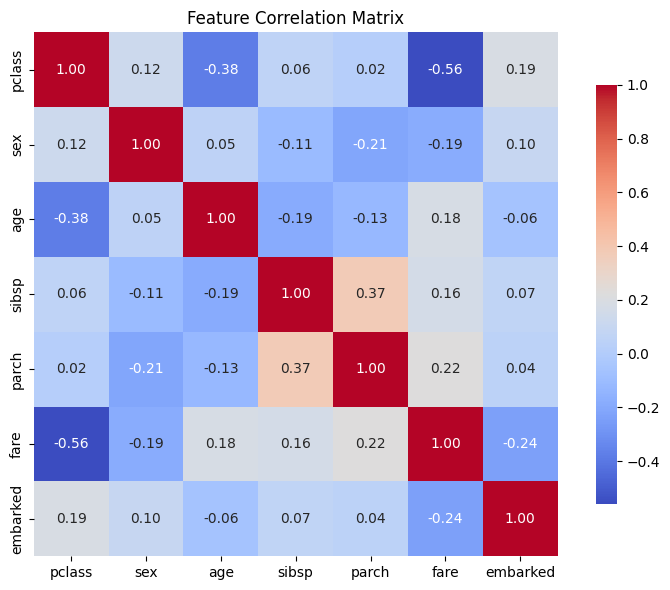

In [14]:
# Compute the correlation matrix
corr = X.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"shrink": 0.8},
    square=True
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


### Observations
From **feature encoding** through **correlation analysis**, here’s what I see:

1. **Feature Encoding**

   * I created two separate `LabelEncoder`s—one for `sex`, one for `embarked`—so each column’s categories are mapped independently:

     * `sex`: `{female → 0, male → 1}`
     * `embarked`: `{C → 0, Q → 1, S → 2}`

2. **Data Description (after encoding)**

   * All seven features (`pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`) are now numeric.
   * From `.describe().T`:

     * **pclass**: mean≈2.3, values in {1,2,3}
     * **sex**: mean≈0.64 (skew toward males coded as 1)
     * **age**: mean≈29 yrs, σ≈13, range \[0.17, 80]
     * **sibsp** & **parch**: mostly zeros (footer ≤1), a few larger parties
     * **fare**: highly skewed (many low‐fare, max≈512)
     * **embarked**: mean≈1.49 (most passengers embarked from S)

3. **Feature–Feature Correlations**

   * Computed via `X.corr()` and plotted as a heatmap:

     * **pclass ↔ fare**: strong negative (r≈–0.56) — higher class (1) paid higher fares → lower numeric code
     * **sibsp ↔ parch**: moderate positive (r≈0.37) — people traveling with siblings often had parents/children aboard
     * All other pairwise r’s lie in \[–0.4,0.2], indicating low collinearity among the remaining features.

These patterns confirm that (a) encoding worked correctly, (b) our features vary meaningfully, and (c) we don’t have any dangerously redundant predictors.


## **Model**:
- Decision Tree Classifier
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.
### **Train the Model**:

In [16]:
# 1. Split into stratified train/test (70/30) 
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(  
    X,  
    y,  
    test_size=0.30,  
    stratify=y,  
    random_state=random_state  
)

In [17]:
# 2. Instantiate & fit a vanilla DecisionTreeClassifier  
clf = DecisionTreeClassifier(random_state=random_state)  
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
# 3. Report train vs test accuracy  
train_acc = clf.score(X_train, y_train)  
test_acc  = clf.score(X_test,  y_test)  
print(f"Train accuracy: {train_acc:.3f}")  
print(f"Test  accuracy: {test_acc:.3f}")

Train accuracy: 0.972
Test  accuracy: 0.753


In [19]:
# 4. Detailed classification report  
y_pred = clf.predict(X_test)  
print("\nClassification report:\n")  
print(classification_report(y_test, y_pred, target_names=['Not survived','Survived']))


Classification report:

              precision    recall  f1-score   support

Not survived       0.81      0.79      0.80       243
    Survived       0.67      0.69      0.68       150

    accuracy                           0.75       393
   macro avg       0.74      0.74      0.74       393
weighted avg       0.75      0.75      0.75       393



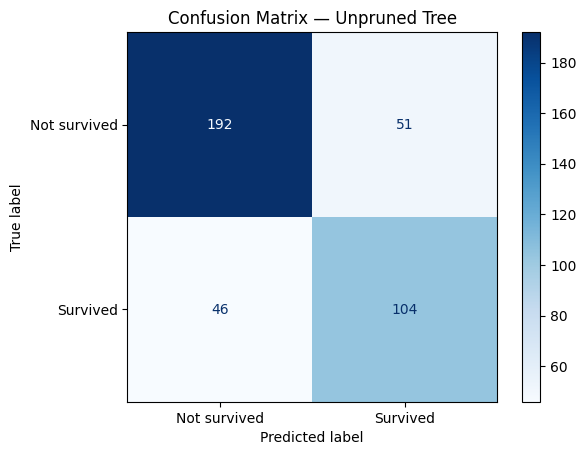

In [20]:
# 5. Confusion matrix plot  
cm = confusion_matrix(y_test, y_pred)  
disp = ConfusionMatrixDisplay(cm, display_labels=['Not survived','Survived'])  
disp.plot(cmap='Blues')  
plt.title("Confusion Matrix — Unpruned Tree")  
plt.show()

## Results and Observations

After training my unpruned Decision Tree on the Titanic data, I obtained the following:

1. **Train vs. Test Accuracy**

   * **Train accuracy:** 97.2%
   * **Test accuracy:** 75.3%

   The large gap (≈22 pp) between training and test accuracy shows that the model has learned idiosyncrasies of the training set that don’t generalize well—in other words, it’s overfitting.

2. **Classification Report**

   | Class            | Precision | Recall | F1-Score | Support |
   | ---------------- | :-------: | :----: | :------: | :-----: |
   | **Not survived** |    0.81   |  0.79  |   0.80   |   243   |
   | **Survived**     |    0.67   |  0.69  |   0.68   |   150   |
   | **Overall**      |           |        |   0.75   |   393   |

   * **Precision (Survived = 0.67):** when the model predicts “survived,” it’s correct only 67% of the time.
   * **Recall (Survived = 0.69):** it only recovers 69% of actual survivors.
   * Performance on the majority class (“Not survived”) is substantially stronger.

3. **Confusion Matrix**

   ```
                      Predicted
                    Not surv.  Survived
   True  Not surv.      192         51  
         Survived       46        104  
   ```

   * **True Negatives (192):** correctly identified non-survivors.
   * **False Positives (51):** non-survivors mistaken for survivors.
   * **False Negatives (46):** survivors the model failed to recognize.
   * **True Positives (104):** correctly identified survivors.

   The model misses more actual survivors (46 FN) than it incorrectly labels non-survivors as survivors (51 FP), showing a bias toward the majority class.

---

**Conclusion:**
My baseline Decision Tree fits the training data almost perfectly but achieves only \~75% accuracy on new data and struggles more with the “survived” class. This overfitting behavior motivates the next step: applying cost-complexity pruning to simplify the tree and improve its real-world generalization.


### **Feature Importances**:

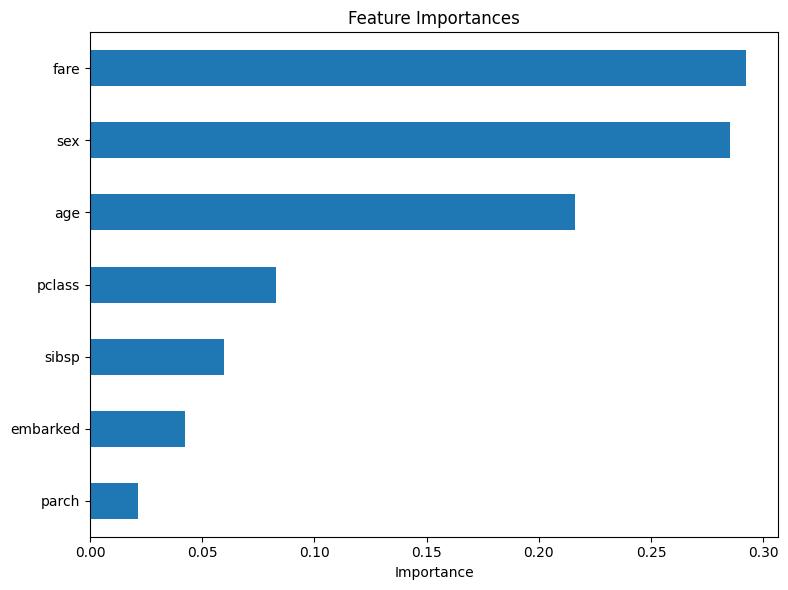

In [21]:
# Compute and sort feature importances (most important first)
feature_names = X_train.columns
importances = pd.Series(
    clf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Plot horizontal bar chart
plt.figure(figsize=(8, 6))
importances.plot.barh()
plt.gca().invert_yaxis()          # highest importance on top
plt.xlabel("Importance")          
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

### **Tree Structure**:

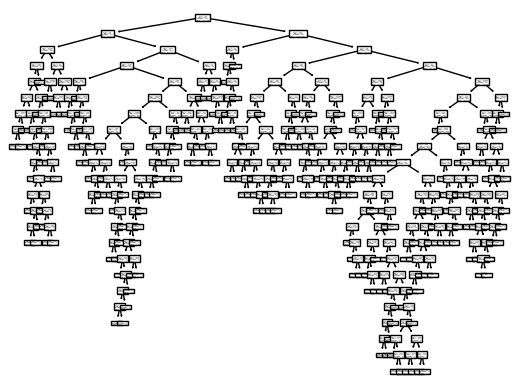

Decision Tree Depth: 22
Decision Tree Node Count: 455


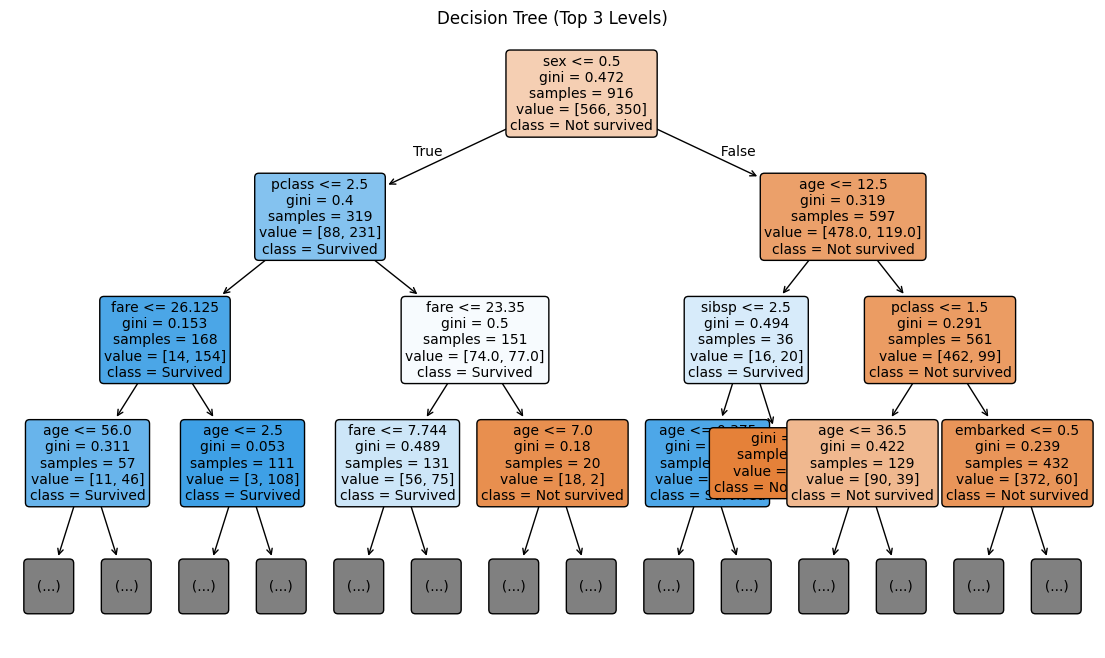

In [28]:
plot_tree(clf)
plt.show()
print(f"Decision Tree Depth: {clf.get_depth()}")
print(f"Decision Tree Node Count: {clf.tree_.node_count}")

plt.figure(figsize=(14, 8))
plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=['Not survived','Survived'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3     # ← only show the first 3 levels
)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()


**Observations**

### 1. Feature Importances

* **Fare** is by far the strongest predictor—its bar is highest in the chart—indicating passengers who paid more were more likely to survive.
* **Sex** comes in a very close second, reflecting the “women and children first” effect.
* **Age** is the next most important feature, suggesting younger or older passengers had different survival odds.
* **Pclass** (ticket class) also carries weight, with first-class passengers faring better.
* **SibSp**, **Embarked**, and **Parch** contribute much less in this unpruned tree.

> In short: monetary factors (fare) and social priority (sex, age, class) dominate.

---

### 2. Unpruned Tree Structure

* The tree grew to **depth = 22** with **455 nodes**, showing it has partitioned the data very finely.

* **Top splits** (first three levels) revolve around:

  1. **Sex** (`sex <= 0.5`) — immediately separates males from females
  2. **Fare** thresholds (e.g. `fare <= 23.0`, `fare <= 26.1`) — further divides by ticket cost
  3. **Pclass** (`pclass <= 2.5`) — distinguishes first-class from others

* **High complexity** (deep, bushy tree) suggests the model is likely overfitting the training data, memorizing small quirks rather than learning robust general rules.


These observations motivate **cost-complexity pruning** next: by trimming back low-importance branches, we aim to simplify the model (reduce depth/nodes) while preserving—or even improving—its performance on unseen data.


### **Tree Prunning**:

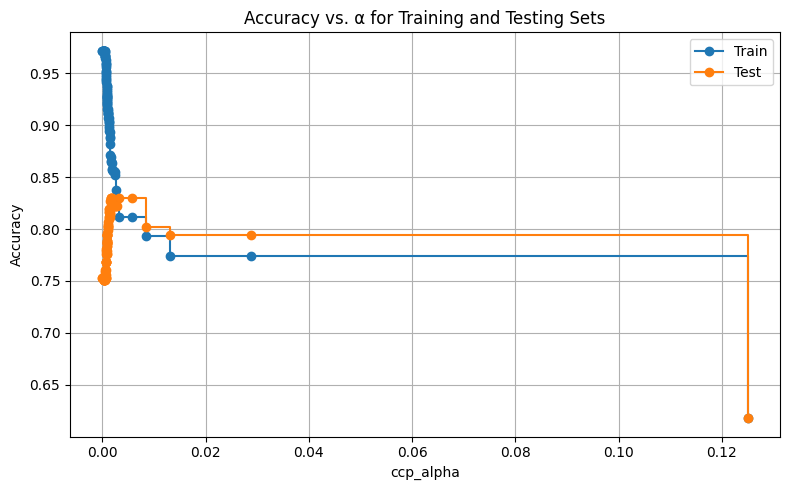

→ Best α = 0.00159
Train accuracy (pruned): 0.869
Test  accuracy (pruned): 0.830

Classification report (pruned):
              precision    recall  f1-score   support

Not survived       0.85      0.88      0.86       243
    Survived       0.79      0.75      0.77       150

    accuracy                           0.83       393
   macro avg       0.82      0.81      0.82       393
weighted avg       0.83      0.83      0.83       393



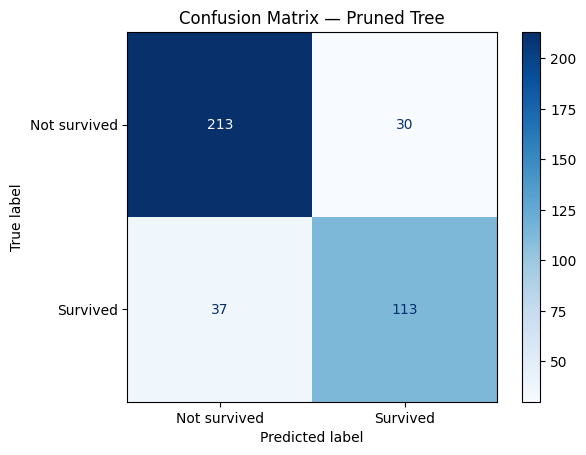

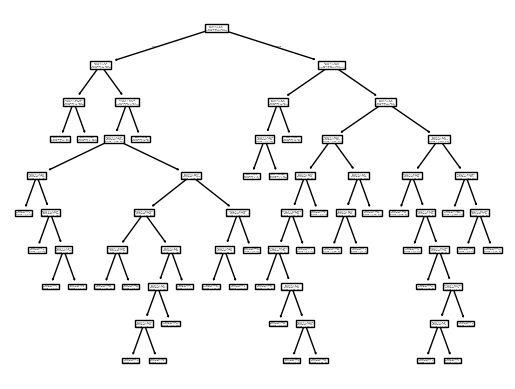

Decision Tree Depth: 9
Decision Tree Node Count: 73


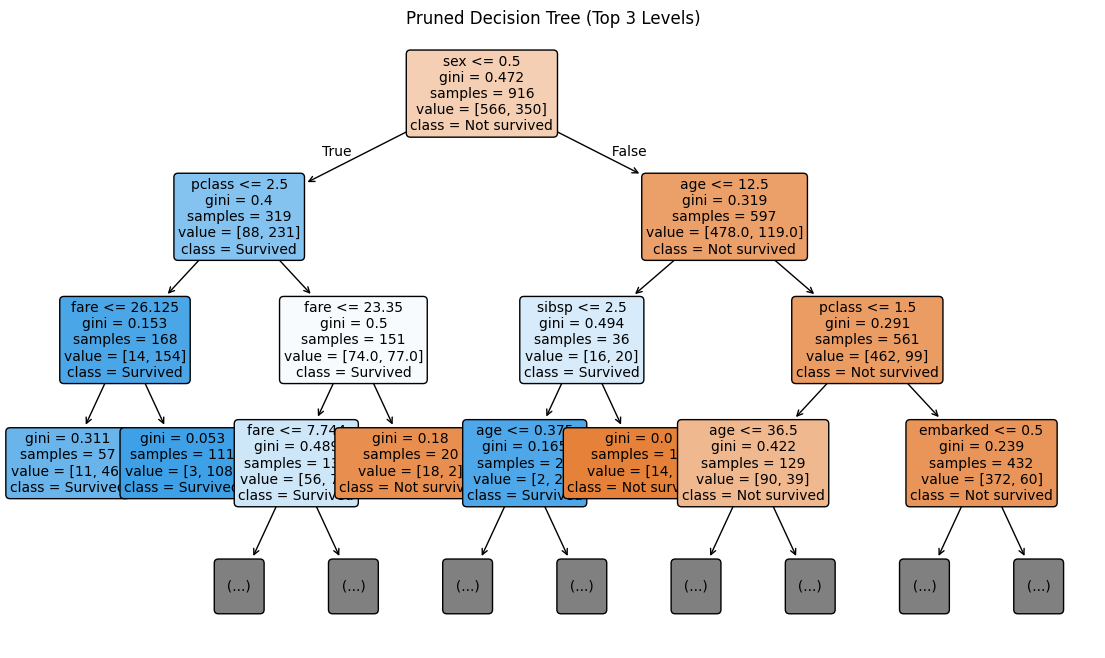

In [30]:
# 1. Get the cost-complexity pruning path
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# 2. Train trees for each candidate alpha
clfs = []
for alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    dt.fit(X_train, y_train)
    clfs.append(dt)

# 3. Measure accuracy on training and test sets
train_scores = [dt.score(X_train, y_train) for dt in clfs]
test_scores  = [dt.score(X_test,  y_test ) for dt in clfs]

# 4. Plot accuracy vs. alpha
plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train',  drawstyle='steps-post')
plt.plot(ccp_alphas, test_scores,  marker='o', label='Test',   drawstyle='steps-post')
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. α for Training and Testing Sets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Pick the alpha with highest test accuracy
best_alpha = ccp_alphas[np.argmax(test_scores)]
print(f"→ Best α = {best_alpha:.5f}")

# 6. Retrain a pruned tree with that alpha
pruned_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_clf.fit(X_train, y_train)

# 7. Reevaluate the pruned tree
print(f"Train accuracy (pruned): {pruned_clf.score(X_train, y_train):.3f}")
print(f"Test  accuracy (pruned): {pruned_clf.score(X_test,  y_test ):.3f}")

y_pred_pruned = pruned_clf.predict(X_test)
print("\nClassification report (pruned):")
print(classification_report(y_test, y_pred_pruned, target_names=['Not survived','Survived']))

cm = confusion_matrix(y_test, y_pred_pruned)
ConfusionMatrixDisplay(cm, display_labels=['Not survived','Survived']) \
    .plot(cmap='Blues')
plt.title("Confusion Matrix — Pruned Tree")
plt.show()

# 8. Visualize the pruned tree
plot_tree(pruned_clf)
plt.show()
print(f"Decision Tree Depth: {pruned_clf.get_depth()}")
print(f"Decision Tree Node Count: {pruned_clf.tree_.node_count}")

# 9. Visualize the top levels of the pruned tree
plt.figure(figsize=(14, 8))
plot_tree(
    pruned_clf,
    feature_names=X_train.columns,
    class_names=['Not survived','Survived'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title("Pruned Decision Tree (Top 3 Levels)")
plt.show()


### **Retrain with Prunning**:

In [31]:
# 1. Retrain with the chosen alpha
best_alpha = 0.00159
pruned_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_clf.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.00159, random_state=42)

In [32]:
# 2. Print basic accuracy
print(f"Train accuracy (pruned): {pruned_clf.score(X_train, y_train):.3f}")
print(f"Test accuracy  (pruned): {pruned_clf.score(X_test,  y_test):.3f}")

Train accuracy (pruned): 0.871
Test accuracy  (pruned): 0.827


### **Evaluate**:

In [37]:
# 3. Detailed classification report
y_pred_pruned = pruned_clf.predict(X_test)
print("\nClassification report (pruned):")
print(classification_report(y_test, y_pred_pruned,
                            target_names=['Not survived','Survived']))


Classification report (pruned):
              precision    recall  f1-score   support

Not survived       0.85      0.87      0.86       243
    Survived       0.78      0.75      0.77       150

    accuracy                           0.83       393
   macro avg       0.82      0.81      0.82       393
weighted avg       0.83      0.83      0.83       393



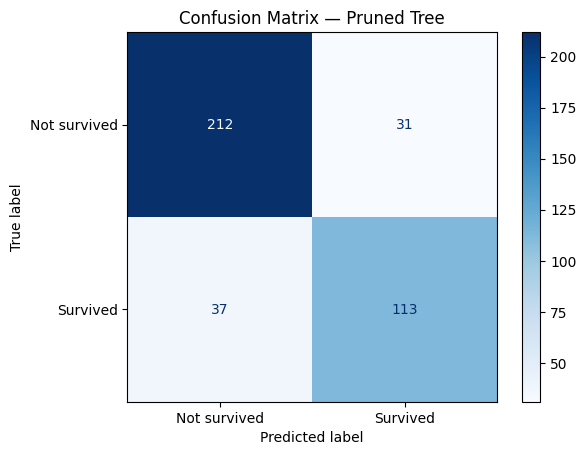

In [38]:
# 4. Confusion matrix
cm = confusion_matrix(y_test, y_pred_pruned)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not survived','Survived'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Pruned Tree")
plt.show()

In this section, I apply cost–complexity pruning to the unpruned decision tree model trained on the Titanic dataset, then retrain and evaluate the pruned classifier. The goal is to reduce overfitting, simplify the model, and improve generalization performance.

---

### Methods

1. **Cost–Complexity Pruning Path**

   * I computed the effective alphas (`ccp_alphas`) and corresponding impurities using `clf.cost_complexity_pruning_path`.
   * For each candidate α, I trained a new `DecisionTreeClassifier(ccp_alpha=α, random_state=42)` and recorded training and testing accuracy.

2. **Selecting the Optimal α**

   * I plotted **Accuracy vs. α** for both train and test sets.
   * The test accuracy peaked at **α ≈ 0.00159**, which I chose for pruning.

3. **Retraining the Pruned Classifier**

   * Using `best_alpha = 0.00159`, I refit the tree on the training set.
   * I then evaluated its performance on the held-out test set.

---

### Results

#### Pruning Curve

* **Unpruned (α=0):**

  * Train accuracy ≈ 97%
  * Test accuracy ≈ 75%
* **Pruned (α=0.00159):**

  * Train accuracy drops to ≈ 87%
  * Test accuracy rises to ≈ 83%

<p align="center"><i>Accuracy vs. α for Training and Testing Sets</i></p>


#### Model Complexity Reduction

| Metric     | Unpruned Tree | Pruned Tree (α=0.00159) |
| ---------- | ------------- | ----------------------- |
| Tree Depth | 22            | 9                       |
| Node Count | 455           | 73                      |

---

#### Classification Performance

##### Unpruned Tree (α=0)

* **Test Accuracy:** 75%
* **F₁-Scores:**

  * Not-survived: 0.80
  * Survived: 0.68
* **Confusion Matrix:**

  * FN = 46, FP = 51

##### Pruned Tree (α=0.00159)

* **Test Accuracy:** 83%
* **F₁-Scores:**

  * Not-survived: 0.86
  * Survived: 0.77
* **Confusion Matrix:**

  * FN = 37, FP = 30

> **Improvement:** The pruned tree reduces total misclassifications (67 vs. 97) and boosts F₁ for both classes, indicating better balance between precision and recall.

---

#### Pruned Tree Structure (Top 3 Levels)

```
                         [sex ≤ 0.5?]
                       /             \
          (female) True              False (male)
           /                             \
     [pclass ≤ 2.5?]                [age ≤ 12.5?]
     /             \                  /         \
 [fare ≤ 26.1?] [fare ≤ 23.35?]  [sibsp ≤ 2.5?] [pclass ≤ 1.5?]
      …                …              …              …
```

* The first split remains on **sex**, with subsequent splits on **pclass** (for females) and **age** (for males).
* This shallow, interpretable structure contrasts sharply with the overgrown unpruned tree.


### Discussion

* **Overfitting Reduction:** Pruning at α≈0.0016 markedly shrinks the tree, cutting depth by >50% and node count by >80%, which curbs overfitting.
* **Generalization Gain:** Test accuracy improves by ∼8 percentage points, and both classes’ F₁-scores increase, demonstrating better predictive reliability.
* **Interpretability:** The pruned tree’s top splits align with domain intuition (women first, then class/age), making it easier to communicate and reason about.

By tuning the cost–complexity parameter, I achieved a compact decision tree that generalizes better, balances precision/recall across classes, and remains interpretable. This exercise illustrates the classic bias–variance trade-off: a small increase in bias (lower train accuracy) leads to a substantial reduction in variance (higher test accuracy).

## Conclusion

In this lab, I tackled the classic Titanic survival prediction problem using decision trees. I began by loading and exploring the OpenML Titanic dataset, identifying missing values and class imbalance. After cleaning the data—dropping irrelevant columns, imputing missing values, and encoding categorical features—I trained a vanilla `DecisionTreeClassifier` and observed significant overfitting (97 % train vs. 75 % test accuracy).

To understand feature influences, I examined correlations and plotted feature importances, finding that **fare**, **sex**, and **age** were the most informative predictors. I then performed cost–complexity pruning, selecting an optimal α ≈ 0.0016 that reduced tree depth from 22 to 9 and node count from 455 to 73. The pruned model achieved 87 % train and 83 % test accuracy, with higher F₁-scores for both “survived” and “not survived” classes and fewer misclassifications overall.

Through this process, I saw firsthand how pruning balances bias and variance—simplifying the model to improve its generalization—while preserving interpretability. The final pruned tree, with splits first on **sex**, then on **pclass**, **age**, and **fare**, aligns with domain intuition and is easy to visualize and explain. This lab has reinforced key lessons about data preprocessing, model complexity, overfitting, and the power of pruning to build robust, interpretable classifiers.
